# SGD stability on MNIST

このノートブックでは、次の 2 段階で実験します。

1. MNIST から 10,000 サンプルを取り、100 エポック学習して事前学習モデルを作る
2. 事前学習に使っていない別の 5,000 サンプルを取り、そのうち 1 点だけ差し替えたデータセットを複数作って、最終パラメータの近さを比較する

後半の比較では、各試行で **同じ事前学習済み初期値**・**同じミニバッチ順**・**同じ最適化設定**を使います。


In [2]:
import copy
import gzip
import importlib
import random
import struct
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.nn.utils import parameters_to_vector

import objective_function.mnist_dnn as mnist_dnn

importlib.reload(mnist_dnn)

make_mnist_dnn = mnist_dnn.make_mnist_dnn

seed = 1234
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.use_deterministic_algorithms(False)
torch.set_num_threads(1)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.set_default_dtype(dtype)

print(f"torch: {torch.__version__}")
print(f"device: {device}")
if torch.cuda.is_available():
    print(f"gpu: {torch.cuda.get_device_name(0)}")
print(f"seed: {seed}")
print("determinism: fixed seed + fixed batch order")
print(f"deterministic algorithms enabled: {torch.are_deterministic_algorithms_enabled()}")


torch: 2.5.1+cu121
device: cuda
gpu: Tesla T4
seed: 1234
determinism: fixed seed + fixed batch order
deterministic algorithms enabled: False


In [3]:
DATA_DIR = Path("data/mnist")
DATA_DIR.mkdir(parents=True, exist_ok=True)

MNIST_URLS = {
    "train_images": "https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz",
    "train_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz",
    "test_images": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz",
}

def download(url: str, path: Path) -> None:
    if path.exists():
        print(f"cached: {path.name}")
        return
    print(f"downloading: {url}")
    urllib.request.urlretrieve(url, path)

def read_idx_images(path: Path) -> torch.Tensor:
    with gzip.open(path, "rb") as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"unexpected image magic number: {magic}")
        data = torch.frombuffer(f.read(), dtype=torch.uint8).clone()
    return data.view(num_images, rows, cols).float().div_(255.0)

def read_idx_labels(path: Path) -> torch.Tensor:
    with gzip.open(path, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"unexpected label magic number: {magic}")
        data = torch.frombuffer(f.read(), dtype=torch.uint8).clone()
    return data.view(num_labels).long()

for name, url in MNIST_URLS.items():
    filename = url.rsplit("/", 1)[-1]
    download(url, DATA_DIR / filename)

x_train = read_idx_images(DATA_DIR / "train-images-idx3-ubyte.gz")
y_train = read_idx_labels(DATA_DIR / "train-labels-idx1-ubyte.gz")
x_test = read_idx_images(DATA_DIR / "t10k-images-idx3-ubyte.gz")
y_test = read_idx_labels(DATA_DIR / "t10k-labels-idx1-ubyte.gz")

print("train:", x_train.shape, y_train.shape)
print("test :", x_test.shape, y_test.shape)


cached: train-images-idx3-ubyte.gz
cached: train-labels-idx1-ubyte.gz
cached: t10k-images-idx3-ubyte.gz
cached: t10k-labels-idx1-ubyte.gz


train: torch.Size([60000, 28, 28]) torch.Size([60000])
test : torch.Size([10000, 28, 28]) torch.Size([10000])


/tmp/ipykernel_114528/588274869.py:23: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:1560.)
  data = torch.frombuffer(f.read(), dtype=torch.uint8).clone()


In [14]:
pretrain_size = 20_000
experiment_size = 5_000
batch_size = 64
pretrain_epochs = 100
experiment_epochs = 20
learning_rate = 0.05
weight_decay = 1e-4
hidden_dims = (128, 64)
num_trials = 20

data_rng = random.Random(2024)
all_indices = list(range(len(x_train)))

pretrain_indices = data_rng.sample(all_indices, pretrain_size)
remaining_after_pretrain = [idx for idx in all_indices if idx not in set(pretrain_indices)]
experiment_base_indices = data_rng.sample(remaining_after_pretrain, experiment_size)
remaining_for_replacement = [idx for idx in remaining_after_pretrain if idx not in set(experiment_base_indices)]

x_pretrain = x_train[pretrain_indices].clone()
y_pretrain = y_train[pretrain_indices].clone()
x_base = x_train[experiment_base_indices].clone()
y_base = y_train[experiment_base_indices].clone()

swap_specs = []
used_positions = set()
used_replacements = set()

for trial_id in range(num_trials):
    swap_position = data_rng.randrange(experiment_size)
    while swap_position in used_positions:
        swap_position = data_rng.randrange(experiment_size)
    used_positions.add(swap_position)

    replacement_index = data_rng.choice(remaining_for_replacement)
    while replacement_index in used_replacements:
        replacement_index = data_rng.choice(remaining_for_replacement)
    used_replacements.add(replacement_index)

    swap_specs.append(
        {
            "trial": trial_id + 1,
            "swap_position": swap_position,
            "original_index": experiment_base_indices[swap_position],
            "replacement_index": replacement_index,
            "original_label": int(y_train[experiment_base_indices[swap_position]]),
            "replacement_label": int(y_train[replacement_index]),
        }
    )

print(f"pretrain size   : {pretrain_size}")
print(f"experiment size : {experiment_size}")
print(f"num trials      : {num_trials}")
print(f"pretrain epochs : {pretrain_epochs}")
print(f"experiment epochs: {experiment_epochs}")
print()
for spec in swap_specs:
    print(
        f"trial {spec['trial']}: position={spec['swap_position']}, "
        f"index {spec['original_index']} (label={spec['original_label']}) -> "
        f"index {spec['replacement_index']} (label={spec['replacement_label']})"
    )


pretrain size   : 20000
experiment size : 5000
num trials      : 20
pretrain epochs : 100
experiment epochs: 20

trial 1: position=3095, index 13486 (label=2) -> index 43796 (label=7)
trial 2: position=578, index 9113 (label=6) -> index 42398 (label=3)
trial 3: position=1551, index 15338 (label=6) -> index 31208 (label=6)
trial 4: position=2352, index 23627 (label=0) -> index 33181 (label=8)
trial 5: position=2936, index 32173 (label=7) -> index 26448 (label=3)
trial 6: position=2222, index 3567 (label=1) -> index 26214 (label=9)
trial 7: position=2169, index 46517 (label=2) -> index 41608 (label=3)
trial 8: position=1113, index 48930 (label=3) -> index 45221 (label=1)
trial 9: position=2150, index 10136 (label=1) -> index 33407 (label=3)
trial 10: position=2482, index 33925 (label=4) -> index 26324 (label=3)
trial 11: position=3089, index 16387 (label=4) -> index 42296 (label=7)
trial 12: position=72, index 35456 (label=2) -> index 16571 (label=4)
trial 13: position=1610, index 12297 

In [15]:
def accuracy(model: torch.nn.Module, images: torch.Tensor, labels: torch.Tensor) -> float:
    model.eval()
    with torch.no_grad():
        logits = model(images.to(device))
        pred = logits.argmax(dim=1)
    return (pred.cpu() == labels.cpu()).float().mean().item()

def flatten_parameters(model: torch.nn.Module) -> torch.Tensor:
    return parameters_to_vector([param.detach().cpu() for param in model.parameters()])

def prediction_agreement(model1: torch.nn.Module, model2: torch.nn.Module, images: torch.Tensor) -> float:
    model1.eval()
    model2.eval()
    with torch.no_grad():
        pred1 = model1(images.to(device)).argmax(dim=1).cpu()
        pred2 = model2(images.to(device)).argmax(dim=1).cpu()
    return (pred1 == pred2).float().mean().item()

def train_with_fixed_batches(
    images: torch.Tensor,
    labels: torch.Tensor,
    *,
    initial_state: dict[str, torch.Tensor],
    hidden_dims: tuple[int, ...],
    batch_size: int,
    epochs: int,
    learning_rate: float,
    weight_decay: float,
) -> tuple[torch.nn.Module, list[dict[str, float]]]:
    model = make_mnist_dnn(hidden_dims=hidden_dims, dropout_rate=0.0).to(device)
    model.load_state_dict(copy.deepcopy(initial_state))

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=0.0,
        weight_decay=weight_decay,
    )

    history = []
    images = images.to(device)
    labels = labels.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for start in range(0, len(images), batch_size):
            stop = start + batch_size
            xb = images[start:stop]
            yb = labels[start:stop]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = torch.nn.functional.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(xb)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_count += len(xb)

        history.append(
            {
                "epoch": epoch,
                "train_loss": total_loss / total_count,
                "train_acc": total_correct / total_count,
            }
        )

    return model, history

def make_swapped_dataset(
    base_indices: list[int],
    *,
    swap_position: int,
    replacement_index: int,
) -> tuple[torch.Tensor, torch.Tensor, list[int]]:
    swapped_indices = base_indices.copy()
    swapped_indices[swap_position] = replacement_index
    return x_train[swapped_indices].clone(), y_train[swapped_indices].clone(), swapped_indices

torch.manual_seed(999)
random_init_model = make_mnist_dnn(hidden_dims=hidden_dims, dropout_rate=0.0).to(device)
random_initial_state = {name: tensor.detach().cpu().clone() for name, tensor in random_init_model.state_dict().items()}

pretrained_model, pretrain_history = train_with_fixed_batches(
    x_pretrain,
    y_pretrain,
    initial_state=random_initial_state,
    hidden_dims=hidden_dims,
    batch_size=batch_size,
    epochs=pretrain_epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
)

pretrained_state = {name: tensor.detach().cpu().clone() for name, tensor in pretrained_model.state_dict().items()}
theta_pretrained = flatten_parameters(pretrained_model)
pretrain_train_acc = accuracy(pretrained_model, x_pretrain, y_pretrain)
pretrain_test_acc = accuracy(pretrained_model, x_test, y_test)

base_model, base_history = train_with_fixed_batches(
    x_base,
    y_base,
    initial_state=pretrained_state,
    hidden_dims=hidden_dims,
    batch_size=batch_size,
    epochs=experiment_epochs,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
)

theta_base = flatten_parameters(base_model)
base_train_acc = accuracy(base_model, x_base, y_base)
base_test_acc = accuracy(base_model, x_test, y_test)

trial_results = []
trial_histories = []
trial_models = []
trial_thetas = []

for spec in swap_specs:
    x_swap, y_swap, swapped_indices = make_swapped_dataset(
        experiment_base_indices,
        swap_position=spec['swap_position'],
        replacement_index=spec['replacement_index'],
    )

    model_swap, history_swap = train_with_fixed_batches(
        x_swap,
        y_swap,
        initial_state=pretrained_state,
        hidden_dims=hidden_dims,
        batch_size=batch_size,
        epochs=experiment_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
    )

    theta_swap = flatten_parameters(model_swap)
    distance_l2 = torch.linalg.vector_norm(theta_base - theta_swap).item()
    relative_l2 = distance_l2 / torch.linalg.vector_norm(theta_base).item()
    max_abs_diff = (theta_base - theta_swap).abs().max().item()
    cosine_similarity = torch.nn.functional.cosine_similarity(
        theta_base.unsqueeze(0), theta_swap.unsqueeze(0)
    ).item()

    train_acc_swap = accuracy(model_swap, x_swap, y_swap)
    test_acc_swap = accuracy(model_swap, x_test, y_test)
    agreement_test = prediction_agreement(base_model, model_swap, x_test)

    result = {
        **spec,
        'train_acc_swap': train_acc_swap,
        'test_acc_swap': test_acc_swap,
        'delta_train_acc_vs_base': train_acc_swap - base_train_acc,
        'delta_test_acc_vs_base': test_acc_swap - base_test_acc,
        'parameter_l2_distance': distance_l2,
        'relative_l2_distance': relative_l2,
        'max_abs_parameter_diff': max_abs_diff,
        'cosine_similarity': cosine_similarity,
        'prediction_agreement_test': agreement_test,
    }
    trial_results.append(result)
    trial_histories.append(history_swap)
    trial_models.append(model_swap)
    trial_thetas.append(theta_swap)

print(f"pretrain train accuracy: {pretrain_train_acc:.4f}")
print(f"pretrain test accuracy : {pretrain_test_acc:.4f}")
print(f"base train accuracy    : {base_train_acc:.4f}")
print(f"base test accuracy     : {base_test_acc:.4f}")
print()
for result in trial_results:
    print(
        f"trial {result['trial']}: "
        f"L2={result['parameter_l2_distance']:.6f}, "
        f"rel={result['relative_l2_distance']:.6%}, "
        f"max_diff={result['max_abs_parameter_diff']:.6e}, "
        f"cos={result['cosine_similarity']:.10f}, "
        f"test_agreement={result['prediction_agreement_test']:.4%}"
    )


pretrain train accuracy: 1.0000
pretrain test accuracy : 0.9682
base train accuracy    : 1.0000
base test accuracy     : 0.9682

trial 1: L2=0.044884, rel=0.255902%, max_diff=4.130040e-03, cos=0.9999965429, test_agreement=99.9700%
trial 2: L2=0.008646, rel=0.049296%, max_diff=4.685968e-04, cos=0.9999997616, test_agreement=100.0000%
trial 3: L2=0.049117, rel=0.280037%, max_diff=4.178669e-03, cos=0.9999960661, test_agreement=99.9800%
trial 4: L2=0.069891, rel=0.398480%, max_diff=5.588467e-03, cos=0.9999923706, test_agreement=99.9600%
trial 5: L2=0.199671, rel=1.138416%, max_diff=1.226051e-02, cos=0.9999352694, test_agreement=99.8600%
trial 6: L2=0.230417, rel=1.313710%, max_diff=1.253127e-02, cos=0.9999136925, test_agreement=99.8300%
trial 7: L2=0.003888, rel=0.022165%, max_diff=2.332116e-04, cos=1.0000000000, test_agreement=100.0000%
trial 8: L2=0.347568, rel=1.981644%, max_diff=1.982702e-02, cos=0.9998036623, test_agreement=99.7900%
trial 9: L2=0.004443, rel=0.025331%, max_diff=2.86467

In [16]:
def summarize_metric(name: str) -> None:
    values = torch.tensor([row[name] for row in trial_results], dtype=torch.float64)
    print(
        f"{name:>24} | "
        f"mean={values.mean().item():.6f}, "
        f"std={values.std(unbiased=False).item():.6f}, "
        f"min={values.min().item():.6f}, "
        f"max={values.max().item():.6f}"
    )

print("summary over swap trials")
summarize_metric('parameter_l2_distance')
summarize_metric('relative_l2_distance')
summarize_metric('max_abs_parameter_diff')
summarize_metric('cosine_similarity')
summarize_metric('prediction_agreement_test')
summarize_metric('delta_train_acc_vs_base')
summarize_metric('delta_test_acc_vs_base')

print()
print(f"distance from pretrained to base: {torch.linalg.vector_norm(theta_pretrained - theta_base).item():.6f}")
print(f"relative distance from pretrained to base: {(torch.linalg.vector_norm(theta_pretrained - theta_base) / torch.linalg.vector_norm(theta_base)).item():.6%}")

print()
print("detailed results")
for row in trial_results:
    print(row)


summary over swap trials
   parameter_l2_distance | mean=0.096598, std=0.109615, min=0.000015, max=0.347568
    relative_l2_distance | mean=0.005507, std=0.006250, min=0.000001, max=0.019816
  max_abs_parameter_diff | mean=0.007144, std=0.008141, min=0.000001, max=0.025731
       cosine_similarity | mean=0.999965, std=0.000054, min=0.999804, max=1.000000
prediction_agreement_test | mean=0.999320, std=0.000833, min=0.997800, max=1.000000
 delta_train_acc_vs_base | mean=0.000000, std=0.000000, min=0.000000, max=0.000000
  delta_test_acc_vs_base | mean=-0.000095, std=0.000177, min=-0.000500, max=0.000200

distance from pretrained to base: 2.098747
relative distance from pretrained to base: 11.965914%

detailed results
{'trial': 1, 'swap_position': 3095, 'original_index': 13486, 'replacement_index': 43796, 'original_label': 2, 'replacement_label': 7, 'train_acc_swap': 1.0, 'test_acc_swap': 0.9682999849319458, 'delta_train_acc_vs_base': 0.0, 'delta_test_acc_vs_base': 9.995698928833008e-05, 

PCA rank used for variance: 21 components
PC1 explained variance      : 91.74%
PC1+PC2 cumulative variance: 94.20%
PC1+PC2+PC3 cumulative     : 96.30%

PC01: explained= 91.74%, cumulative= 91.74%
PC02: explained=  2.46%, cumulative= 94.20%
PC03: explained=  2.09%, cumulative= 96.30%
PC04: explained=  1.19%, cumulative= 97.49%
PC05: explained=  0.86%, cumulative= 98.35%
PC06: explained=  0.67%, cumulative= 99.02%
PC07: explained=  0.51%, cumulative= 99.53%
PC08: explained=  0.21%, cumulative= 99.74%
PC09: explained=  0.15%, cumulative= 99.89%
PC10: explained=  0.07%, cumulative= 99.96%


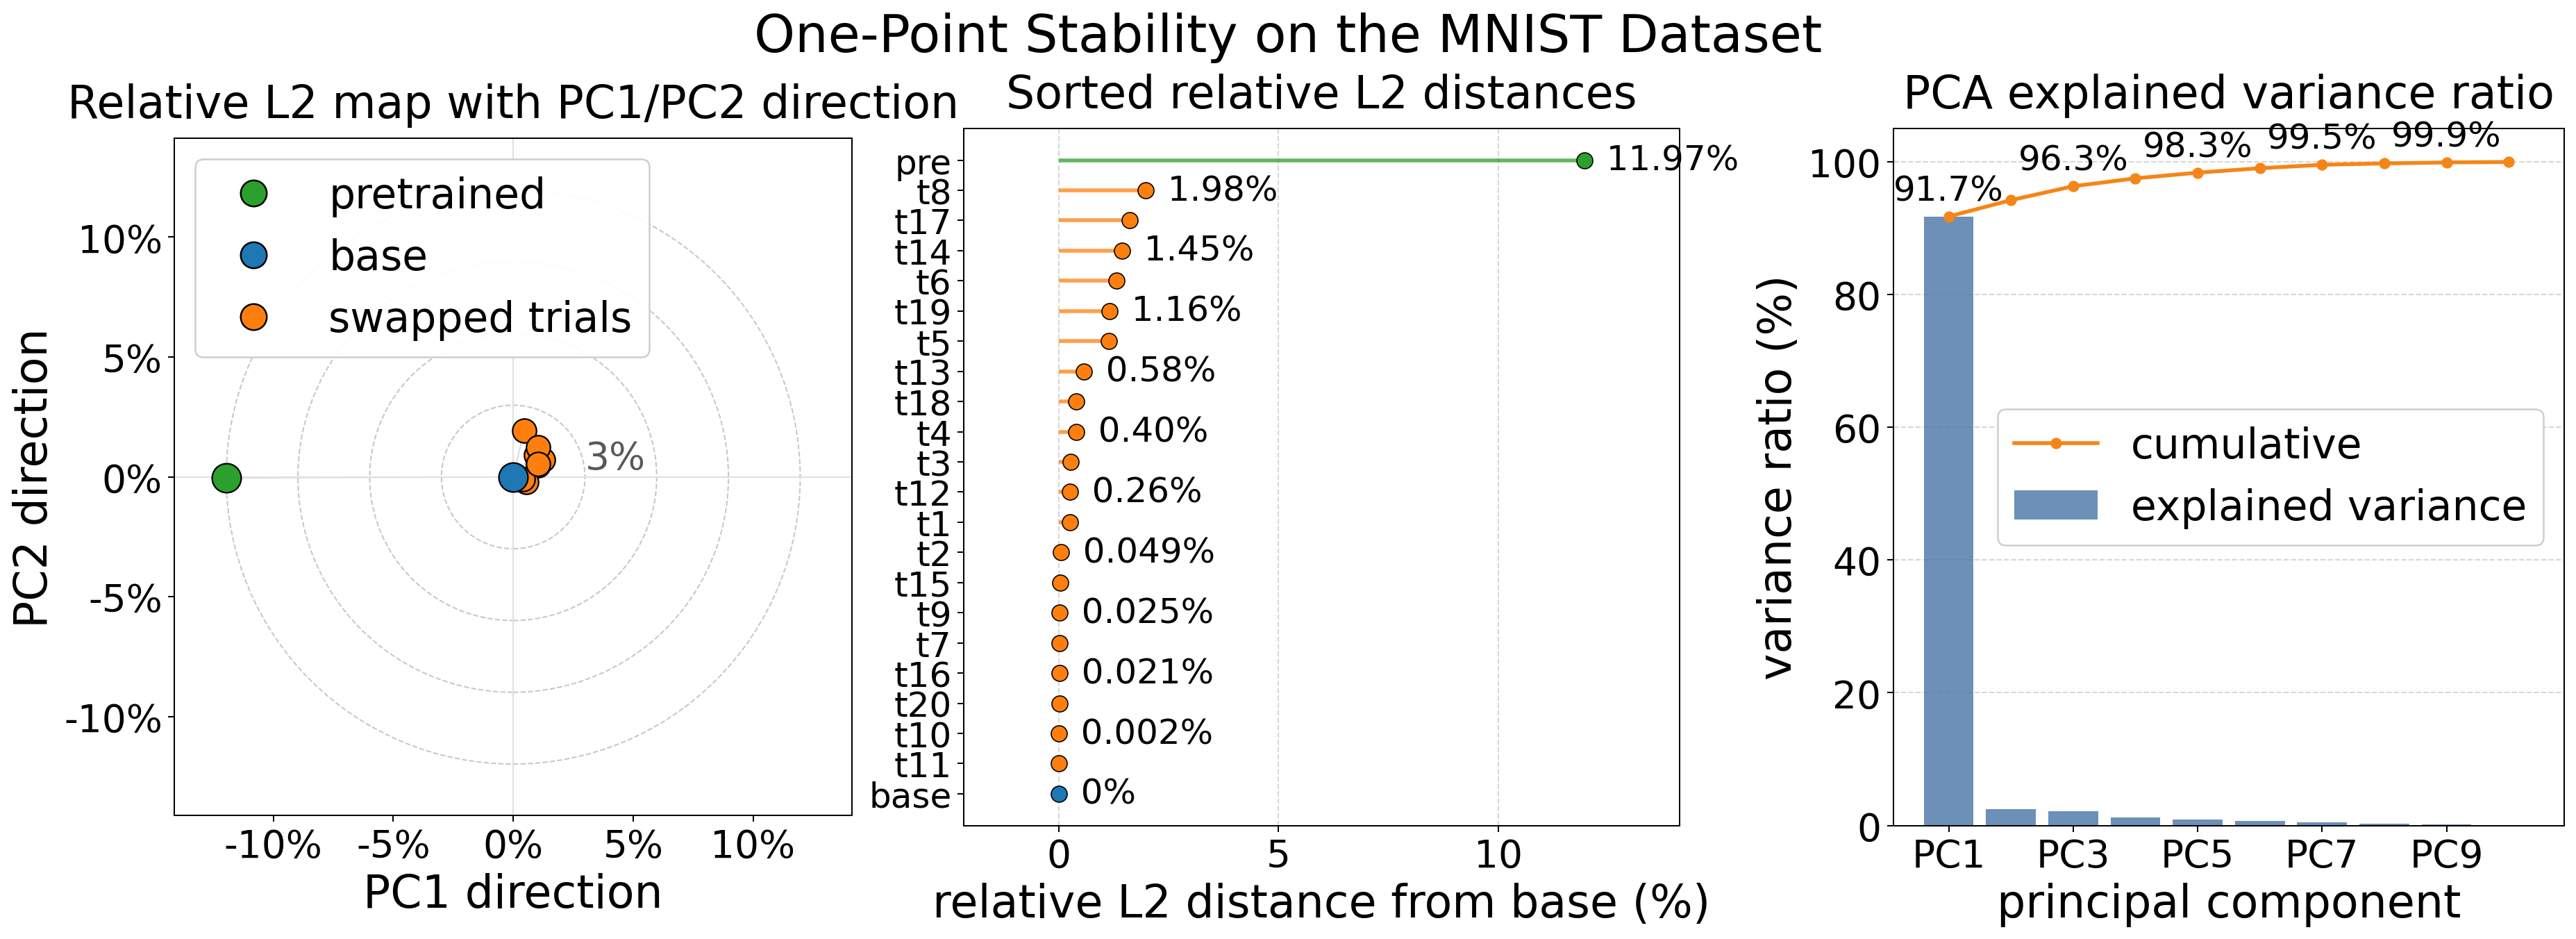

In [109]:
import math

labels = ['pretrained', 'base'] + [f"trial {row['trial']}" for row in trial_results]
short_labels = ['pre', 'base'] + [f"t{row['trial']}" for row in trial_results]
all_thetas = [theta_pretrained, theta_base] + trial_thetas
theta_matrix = torch.stack(all_thetas)
centered = (theta_matrix - theta_base.unsqueeze(0)).detach().cpu().to(torch.float64)
base_norm = torch.linalg.vector_norm(theta_base).item()

relative_l2 = torch.tensor(
    [
        torch.linalg.vector_norm(theta_pretrained - theta_base).item() / base_norm,
        0.0,
    ] + [row['relative_l2_distance'] for row in trial_results],
    dtype=torch.float64,
)
point_colors = ['#2ca02c', '#1f77b4'] + ['#ff7f0e'] * len(trial_results)

# PCA gives the angular direction; the radial distance is exactly relative_l2.
pca_angle_input = centered - centered.mean(dim=0, keepdim=True)
_, _, v_angle = torch.pca_lowrank(pca_angle_input, q=2)
direction_2d = pca_angle_input @ v_angle[:, :2]
direction_norm = torch.linalg.vector_norm(direction_2d, dim=1)
fallback_angles = torch.linspace(0.0, 2.0 * math.pi, len(labels) + 1, dtype=torch.float64)[:-1]
angles = torch.where(direction_norm > 1e-12, torch.atan2(direction_2d[:, 1], direction_2d[:, 0]), fallback_angles)

radial_coords = torch.stack(
    [relative_l2 * torch.cos(angles), relative_l2 * torch.sin(angles)],
    dim=1,
)

# Explained variance from the Gram matrix. This avoids forming a huge covariance matrix.
gram = pca_angle_input @ pca_angle_input.T
eigenvalues, _ = torch.linalg.eigh(gram)
eigenvalues = eigenvalues.flip(0).clamp_min(0.0)
total_variance = eigenvalues.sum()
if total_variance <= 0:
    raise ValueError('PCA explained variance is zero; all parameter vectors may be identical.')

explained_ratio = eigenvalues / total_variance
cumulative_ratio = explained_ratio.cumsum(dim=0)
nonzero_components = int((eigenvalues > eigenvalues.max().clamp_min(1e-30) * 1e-12).sum().item())
n_show = min(10, nonzero_components)

print(f"PCA rank used for variance: {nonzero_components} components")
print(f"PC1 explained variance      : {explained_ratio[0].item():.2%}")
print(f"PC1+PC2 cumulative variance: {cumulative_ratio[1].item():.2%}" if len(cumulative_ratio) > 1 else "PC1+PC2 cumulative variance: n/a")
print(f"PC1+PC2+PC3 cumulative     : {cumulative_ratio[2].item():.2%}" if len(cumulative_ratio) > 2 else "PC1+PC2+PC3 cumulative     : n/a")
print()
for i in range(n_show):
    print(f"PC{i + 1:02d}: explained={explained_ratio[i].item():7.2%}, cumulative={cumulative_ratio[i].item():7.2%}")

def format_relative_percent(value: float) -> str:
    percent = 100.0 * value
    if percent == 0.0:
        return '0%'
    if percent < 0.001:
        return f'{percent:.1e}%'
    if percent < 0.1:
        return f'{percent:.3f}%'
    return f'{percent:.2f}%'

def format_ring_percent(value: float) -> str:
    percent = 100.0 * value
    if percent < 1.0:
        return format_relative_percent(value)
    return f'{percent:.0f}%'

FONT_FIG_TITLE = 30
FONT_PANEL_TITLE = 26
FONT_AXIS_LABEL = 26
FONT_TICK_LABEL = 22
FONT_RING_LABEL = 22
FONT_VALUE_LABEL = 20
FONT_RANK_LABEL = 20
FONT_LEGEND = 24
RADIAL_SPECIAL_POINT_SIZE = 280
RADIAL_TRIAL_POINT_SIZE = 190
RADIAL_LEGEND_MARKER_SIZE = 15

fig_set, (ax_radial, ax_rank, ax_ev) = plt.subplots(
    1,
    3,
    figsize=(20.5, 7.4),
    dpi=180,
    constrained_layout=True,
    gridspec_kw={'width_ratios': (1.06, 1.12, 1.05)},
)

max_radius = max(relative_l2.max().item(), 1e-12)
ring_values = torch.linspace(0.25 * max_radius, max_radius, 4)
for idx, ring in enumerate(ring_values):
    radius = ring.item()
    ax_radial.add_patch(plt.Circle((0.0, 0.0), radius, fill=False, color='0.78', linestyle='--', linewidth=0.8))
    if idx == 0:
        ax_radial.text(radius, 0.0, format_ring_percent(radius), fontsize=FONT_RING_LABEL, color='0.35', va='bottom', ha='left')

coords_np = radial_coords.cpu().numpy()
for i, (x_coord, y_coord) in enumerate(coords_np):
    ax_radial.plot([0.0, x_coord], [0.0, y_coord], color='0.86', linewidth=0.8, zorder=1)
radial_draw_order = list(range(len(coords_np)))
radial_draw_order.remove(1)
radial_draw_order.append(1)
for i in radial_draw_order:
    x_coord, y_coord = coords_np[i]
    point_size = RADIAL_SPECIAL_POINT_SIZE if i < 2 else RADIAL_TRIAL_POINT_SIZE
    point_zorder = 5 if i == 1 else 3
    ax_radial.scatter(x_coord, y_coord, s=point_size, c=point_colors[i], edgecolors='black', linewidths=0.9, zorder=point_zorder)
axis_reference_tick = 0.10
limit = max(max_radius * 1.18, axis_reference_tick * 1.08)
ax_radial.set_xlim(-limit, limit)
ax_radial.set_ylim(-limit, limit)
ax_radial.set_aspect('equal', adjustable='box')
ax_radial.axhline(0.0, color='0.88', linewidth=0.8)
ax_radial.axvline(0.0, color='0.88', linewidth=0.8)
ax_radial.set_title('Relative L2 map with PC1/PC2 direction', fontsize=FONT_PANEL_TITLE, pad=12)
ax_radial.set_xlabel('PC1 direction', fontsize=FONT_AXIS_LABEL)
ax_radial.set_ylabel('PC2 direction', fontsize=FONT_AXIS_LABEL)
tick_values = [-axis_reference_tick, -0.5 * axis_reference_tick, 0.0, 0.5 * axis_reference_tick, axis_reference_tick]
tick_labels = ['-10%', '-5%', '0%', '5%', '10%']
ax_radial.set_xticks(tick_values)
ax_radial.set_yticks(tick_values)
ax_radial.set_xticklabels(tick_labels)
ax_radial.set_yticklabels(tick_labels)
ax_radial.tick_params(axis='both', labelsize=FONT_TICK_LABEL)
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ca02c', markeredgecolor='black', markersize=RADIAL_LEGEND_MARKER_SIZE, label='pretrained'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markeredgecolor='black', markersize=RADIAL_LEGEND_MARKER_SIZE, label='base'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markeredgecolor='black', markersize=RADIAL_LEGEND_MARKER_SIZE, label='swapped trials'),
]
ax_radial.legend(handles=legend_handles, loc='upper left', frameon=True, framealpha=0.95, facecolor='white', edgecolor='0.8', fontsize=FONT_LEGEND)

order = torch.argsort(relative_l2, descending=True).tolist()
y_positions = list(range(len(order)))
rank_values = [relative_l2[i].item() * 100.0 for i in order]
rank_labels = [short_labels[i] for i in order]
rank_colors = [point_colors[i] for i in order]

orange_label_count = 0
for y_pos, value, color in zip(y_positions, rank_values, rank_colors):
    ax_rank.hlines(y_pos, 0.0, value, color=color, linewidth=2.2, alpha=0.75)
    ax_rank.scatter(value, y_pos, s=85, c=color, edgecolors='black', linewidths=0.65, zorder=3)
    show_value = color != '#ff7f0e' or orange_label_count % 2 == 0
    if show_value:
        ax_rank.text(value, y_pos, f'  {format_relative_percent(value / 100.0)}', va='center', fontsize=FONT_VALUE_LABEL)
    if color == '#ff7f0e':
        orange_label_count += 1

ax_rank.set_yticks(y_positions)
ax_rank.set_yticklabels(rank_labels, fontsize=FONT_RANK_LABEL)
ax_rank.invert_yaxis()
ax_rank.set_xlabel('relative L2 distance from base (%)', fontsize=FONT_AXIS_LABEL)
ax_rank.set_title('Sorted relative L2 distances', fontsize=FONT_PANEL_TITLE, pad=12)
ax_rank.tick_params(axis='x', labelsize=FONT_TICK_LABEL)
ax_rank.grid(True, axis='x', linestyle='--', linewidth=0.8, color='0.84')
ax_rank.set_axisbelow(True)
ax_rank.margins(x=0.18)

x_pc = torch.arange(1, n_show + 1).numpy()
bars = explained_ratio[:n_show].cpu().numpy() * 100.0
cum = cumulative_ratio[:n_show].cpu().numpy() * 100.0
ax_ev.bar(x_pc, bars, color='#4c78a8', alpha=0.82, label='explained variance')
ax_ev.plot(x_pc, cum, color='#f58518', marker='o', markersize=5.5, linewidth=2.2, label='cumulative')
for idx, (xi, yi) in enumerate(zip(x_pc, cum)):
    if idx % 2 == 0:
        ax_ev.text(xi, yi + 1.4, f'{yi:.1f}%', ha='center', va='bottom', fontsize=FONT_VALUE_LABEL)

ax_ev.set_title('PCA explained variance ratio', fontsize=FONT_PANEL_TITLE, pad=12)
ax_ev.set_xlabel('principal component', fontsize=FONT_AXIS_LABEL)
ax_ev.set_ylabel('variance ratio (%)', fontsize=FONT_AXIS_LABEL)
ax_ev.set_xticks(x_pc[::2])
ax_ev.set_xticklabels([f'PC{i}' for i in x_pc[::2]], fontsize=FONT_TICK_LABEL)
ax_ev.tick_params(axis='y', labelsize=FONT_TICK_LABEL)
ax_ev.set_ylim(0.0, min(105.0, max(15.0, float(cum.max()) + 8.0)))
ax_ev.grid(True, axis='y', linestyle='--', linewidth=0.8, color='0.84')
ax_ev.set_axisbelow(True)
ax_ev.legend(loc='center right', frameon=True, framealpha=0.95, facecolor='white', edgecolor='0.8', fontsize=FONT_LEGEND)

fig_set.suptitle('One-Point Stability on the MNIST Dataset', fontsize=FONT_FIG_TITLE)
plt.show()


## 読み方

- `pretrained` は 10,000 サンプルで 100 エポック学習したモデルです。
- `base` は、その `pretrained` を初期値として別の 5,000 サンプルで学習した基準モデルです。
- `trial k` は、5,000 サンプルのうち 1 点だけ差し替えたデータセットで学習したモデルです。
- `relative_l2_distance` が小さく、`cosine_similarity` が 1 に近ければ、1 点差し替えても最終パラメータが近いと見なせます。
- `Distance summary from final parameters` は、距離の解釈に必要な 3 つの図を 1 セットにしたものです。左から `base` 中心で半径が `relative_l2_distance` そのものの図、同じ距離の大きい順、PCA の寄与率です。
- `PCA explained variance ratio` は、PC1、PC2、PC3... が全体のばらつきを何%説明しているかを示します。`PC1+PC2` の累積寄与率が低い場合、2D PCA は高次元距離の一部だけを見ている断面図として扱います。
- t-SNE は近い点を近く保つ一方で、点同士を見やすく押し広げる性質があります。そのため PCA よりばらけて見えても、元のパラメータ距離が大きいとは限りません。距離の大きさを見たいときは `Distance summary from final parameters` と MDS を優先します。
